# Visualisation of stats about the graph and the data

## Setup and import data

In [2]:
import pickle
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
inpath='old_outs/out_202405211310'
testSize=''

In [4]:

edge_path = f'{inpath}/edges{testSize}.pkl'
graph_path = f'{inpath}/graph{testSize}.pkl'
tool_path = f'{inpath}/tools{testSize}.pkl'
nr_citations_path = f'{inpath}/nr_citations{testSize}.pkl'
node_degree_dict_path = f'{inpath}/node_degree_dict{testSize}.pkl'

In [5]:
print("Loading saved things.")
with open(edge_path, 'rb') as f:
    unq_edges = pickle.load(f) # edges included in graph, not sure if necessary. list of tuples 

with open(graph_path, 'rb') as f:
    G = pickle.load(f) # graph igraph 

with open(tool_path, 'rb') as f:
    included_tools = pickle.load(f) # tools in graph, list. Maybe do a comparison to the total number of tools, and print the list of tools not included in graph? this for later

with open(nr_citations_path, 'rb') as f: # citations per tool, dict. Histogram frequency of citation nr
    nr_citations = pickle.load(f) 

with open(node_degree_dict_path, 'rb') as f: #degrees per node (ons not tool. Should extraxt only tools using the included tools list), dict. Histogram - frequency of degree (perhaps do this before and after processing of graph (unique edges and only cocitations etc))
    node_degree_dict = pickle.load(f) 

with open('dates.pkl', 'rb') as f: #degrees per node (ons not tool. Should extraxt only tools using the included tools list), dict. Histogram - frequency of degree (perhaps do this before and after processing of graph (unique edges and only cocitations etc))
    publication_dates = pickle.load(f)    

Loading saved things.


## Setup style and colour theme

In [10]:
# Define your custom colours
custom_colours = ['#f2634c', '#d64b3c', '#ce4136', '#000000', '#ffffff']

# Update the default colour cycle
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=custom_colours)

## Finished visualisations

### Visualising number of citations and degrees of each tool!

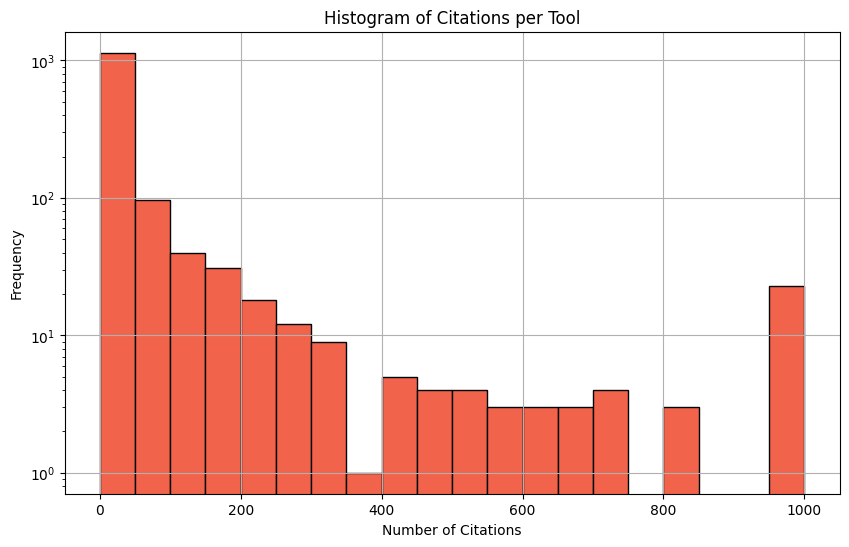

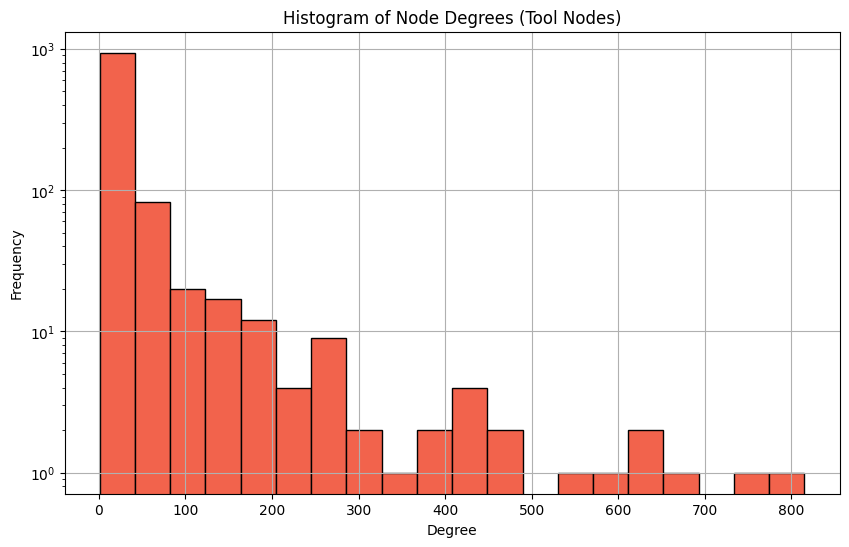

In [11]:
tool_nodes = set(included_tools)
tool_degrees = {node: degree for node, degree in node_degree_dict.items() if node in tool_nodes}

plt.figure(figsize=(10, 6))
plt.hist(nr_citations.values(), bins=20, edgecolor='black')
plt.title('Histogram of Citations per Tool')
plt.xlabel('Number of Citations')
plt.yscale('log')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(tool_degrees.values(), bins=20, edgecolor='black')
plt.title('Histogram of Node Degrees (Tool Nodes)')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.yscale('log')

plt.grid(True)
plt.show()



### Visualising how degree and nr citations cooccur 

Though it is expected that higher degrees in the cocitation graph coincides with a higher nr of citations, it can be good to change this as a sanity check.


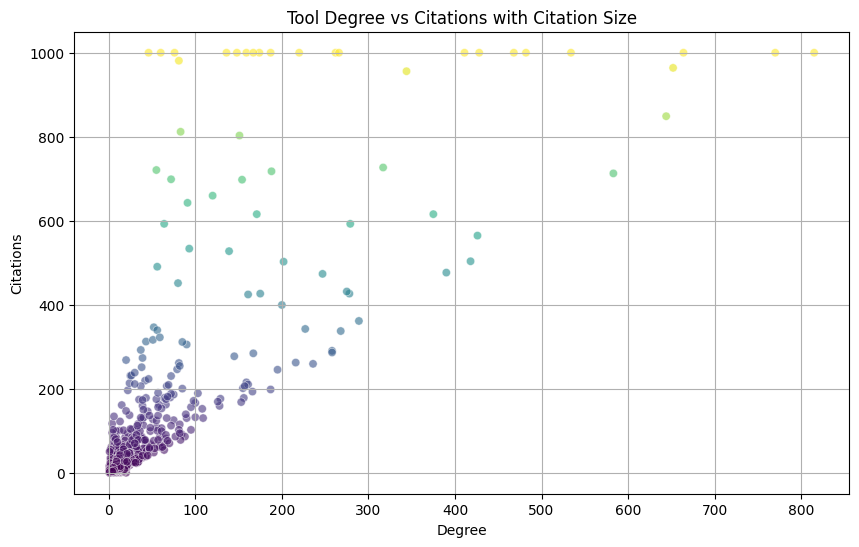

In [84]:
degrees = []
citations = []
sizes = []

for tool in included_tools:
    if tool in tool_degrees:
        degrees.append(tool_degrees[tool])
        citations.append(nr_citations.get(tool, 0))
        sizes.append(nr_citations.get(tool, 0) * 3)  

plt.figure(figsize=(10, 6))
scatter = plt.scatter(degrees, citations, c=sizes, alpha=0.6, edgecolors="w", linewidth=0.5)
# plt.xscale('log')
plt.title('Tool Degree vs Citations with Citation Size')
plt.xlabel('Degree')
plt.ylabel('Citations')
plt.grid(True)


plt.show()

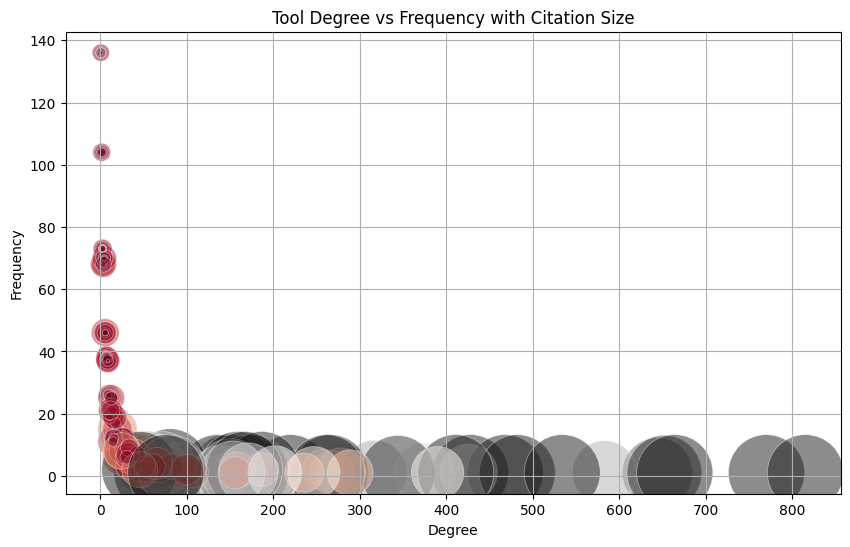

In [32]:
degrees = []
frequencies = []
sizes = []

degree_frequency = {degree: 0 for degree in tool_degrees.values()} 
for degree in tool_degrees.values():
    degree_frequency[degree] += 1

for tool in tool_nodes:
    degrees.append(tool_degrees[tool])
    frequencies.append(degree_frequency[tool_degrees[tool]])
    sizes.append(nr_citations.get(tool, 0) * 3)  

plt.figure(figsize=(10, 6))
plt.scatter(degrees, frequencies, s=sizes, c=sizes, cmap='RdGy', alpha=0.5, edgecolors="w", linewidth=0.5)
plt.title('Tool Degree vs Frequency with Citation Size')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.grid(True)

plt.show()


With logarithmic x-axis

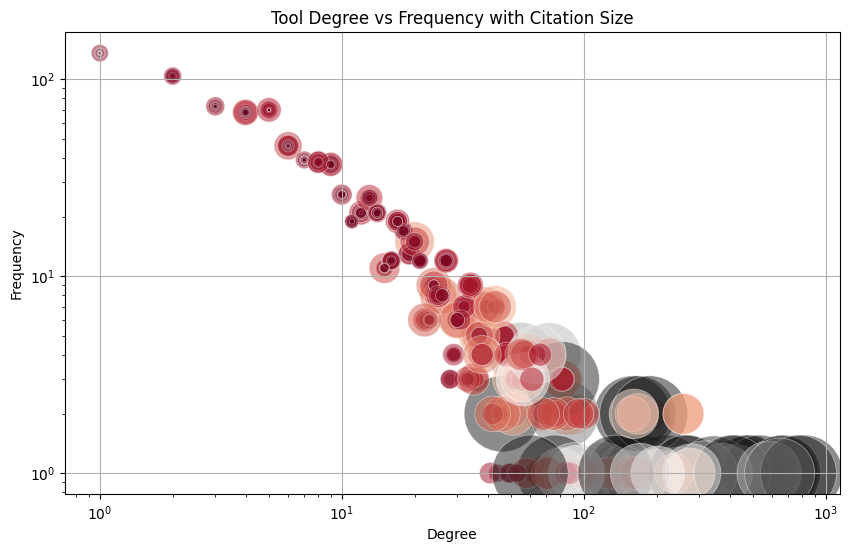

In [13]:
#log x axis

degrees = []
frequencies = []
sizes = []

degree_frequency = {degree: 0 for degree in tool_degrees.values()}
for degree in tool_degrees.values():
    degree_frequency[degree] += 1

for tool in tool_nodes:
    degrees.append(tool_degrees[tool])
    frequencies.append(degree_frequency[tool_degrees[tool]])
    sizes.append(nr_citations.get(tool, 0) * 3)  

plt.figure(figsize=(10, 6))
plt.scatter(degrees, frequencies, s=sizes, c=sizes, cmap='RdGy', alpha=0.5, edgecolors="w", linewidth=0.5)
plt.yscale('log')
plt.xscale('log')
plt.title('Tool Degree vs Frequency with Citation Size')
plt.xlabel('Degree')
plt.ylabel('Frequency')

plt.grid(True)



plt.show()


### Visualising degrees for non tool, citation, nodes

Most importantly we want to know what the degree distribution of the non tool nodes are, so that we can detect ones that perhaps have a suspiciously large nr degrees and exclude them from the final graph. 

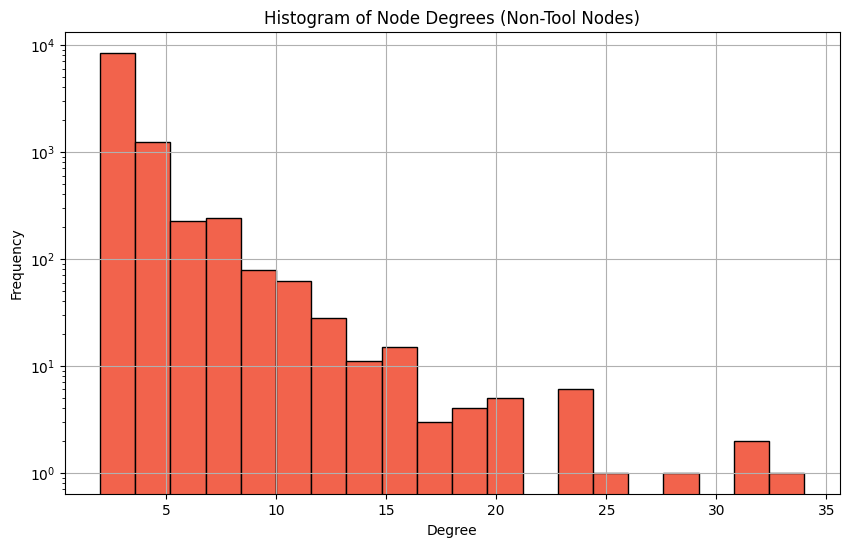

In [87]:
non_tool_nodes = set(node_degree_dict.keys()) - set(included_tools)
non_tool_degrees = {node: degree for node, degree in node_degree_dict.items() if node in non_tool_nodes}

plt.figure(figsize=(10, 6))
plt.hist(non_tool_degrees.values(), bins=20, edgecolor='black')
plt.title('Histogram of Node Degrees (Non-Tool Nodes)')
plt.yscale('log')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

## Future things to implement

In [24]:
import requests
# TODO: improve with asyncio 
def get_publication_date(pmid):
    url = f"https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esummary.fcgi?db=pubmed&id={pmid}&retmode=json"
    response = requests.get(url)
    data = response.json()
    if 'result' in data and pmid in data['result']:
        try:
            pub_date = data['result'][pmid]['pubdate']
            return pub_date
        except:
            return None
    else:
        return None





In [25]:
# testing
pmid = "25631240" # Tandem2XML
date = get_publication_date(pmid)
print("Publication Date:", date)

Publication Date: 2015 Aug


In [98]:
# for all:
import pandas as pd 

df = pd.read_csv('biotools_metadata_topic_0121_20240516.csv')
pmid_list = df['pmid'].tolist()
publication_dates = {}


for pmid in pmid_list: # Dude, just use asyncio this is slow
    date = get_publication_date(str(pmid)) #pmid has to be string
    publication_dates[pmid] = str(date).split()[0] 

In [101]:
with open("dates_1.pkl", "wb") as f:
    pickle.dump(publication_dates, f)

Defining ages and citations, used for plotting below

In [6]:

ages = []
citations = []

for tool, age in publication_dates.items():
    if str(tool) in nr_citations and age != 'None':
        ages.append(int(age))
        citations.append(nr_citations[str(tool)])

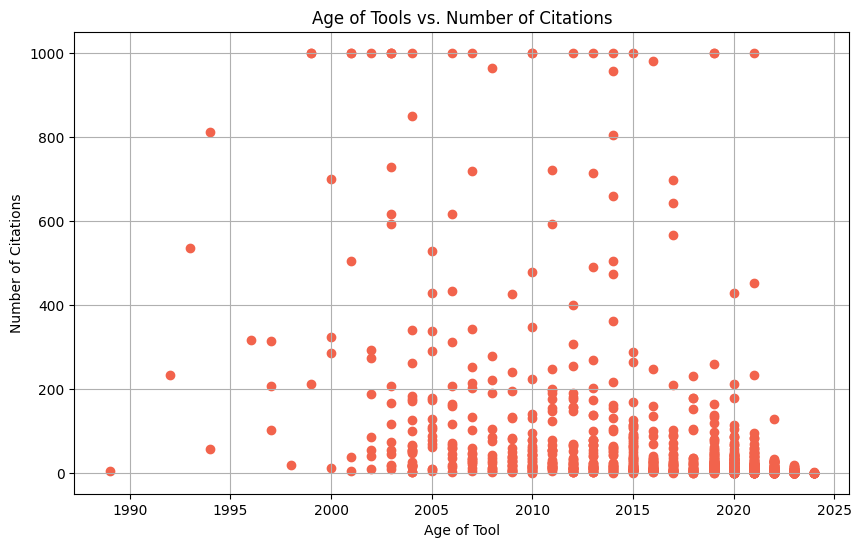

In [27]:
plt.figure(figsize=(10, 6))
plt.scatter(ages, citations)
plt.title('Age of Tools vs. Number of Citations')
plt.xlabel('Age of Tool')
plt.ylabel('Number of Citations')

plt.grid(True)
plt.show()


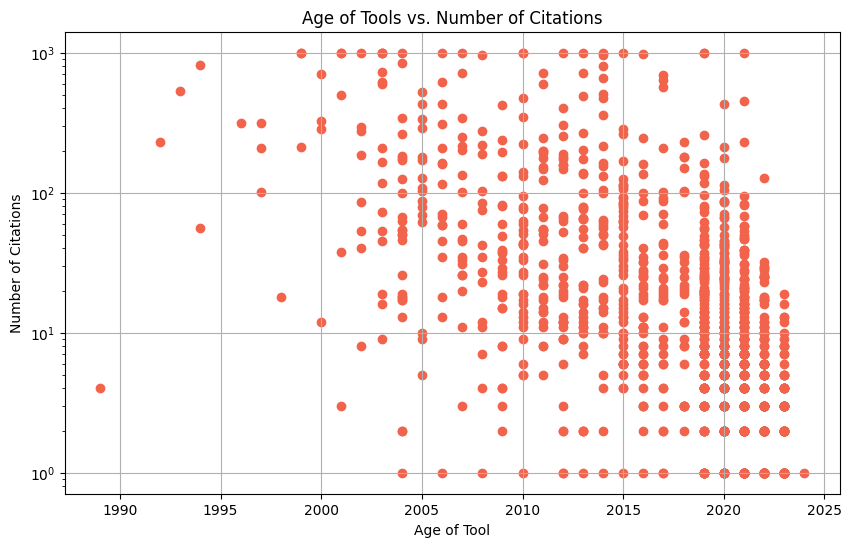

In [9]:

plt.figure(figsize=(10, 6))
plt.scatter(ages, citations)
plt.title('Age of Tools vs. Number of Citations')
plt.xlabel('Age of Tool')
plt.ylabel('Number of Citations')
plt.yscale('log')

plt.grid(True)
plt.show()


Above shows that we really need to fix the fact that the nr citations is being trunkated to 1000

In [ ]:
data = pd.DataFrame({'Age': ages, 'Citations': citations})

mean_citations_per_age = data.groupby('Age')['Citations'].mean()


plt.figure(figsize=(10, 6))
plt.plot(mean_citations_per_age.index, mean_citations_per_age.values, marker='o', linestyle='-')
plt.title('Mean Number of Citations per Year')
plt.xlabel('Age of Tool')
plt.ylabel('Mean Number of Citations')
# plt.yscale('log')  #  log scale

plt.grid(True)
plt.show()


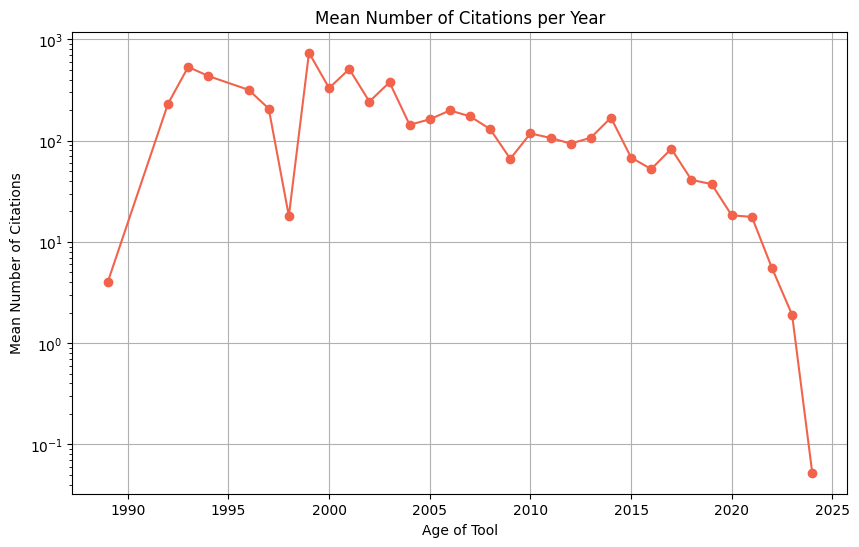

In [12]:
data = pd.DataFrame({'Age': ages, 'Citations': citations})

mean_citations_per_age = data.groupby('Age')['Citations'].mean()


plt.figure(figsize=(10, 6))
plt.plot(mean_citations_per_age.index, mean_citations_per_age.values, marker='o', linestyle='-')
plt.title('Mean Number of Citations per Year')
plt.xlabel('Age of Tool')
plt.ylabel('Mean Number of Citations')
plt.yscale('log')  #  log scale

plt.grid(True)
plt.show()


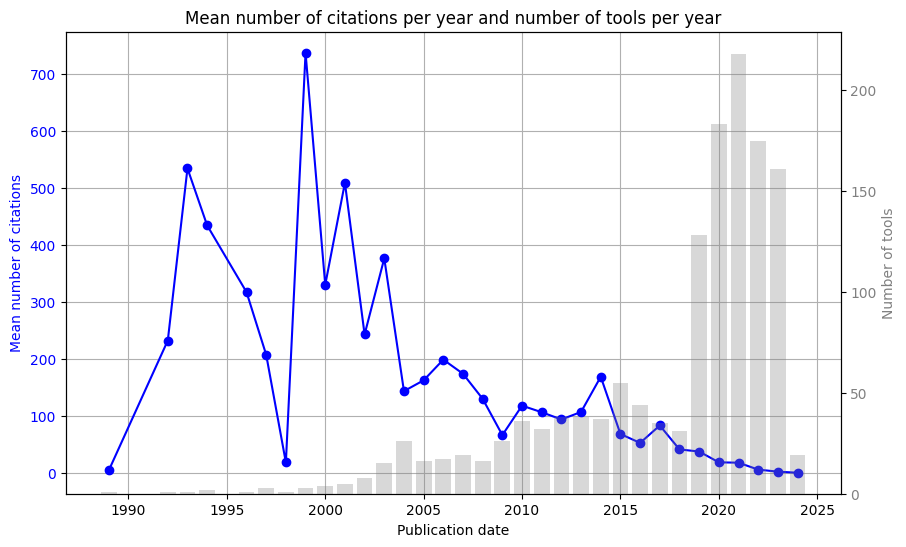

In [7]:

data = pd.DataFrame({'Age': ages, 'Citations': citations})

mean_citations_per_age = data.groupby('Age')['Citations'].mean()
count_per_age = data['Age'].value_counts().sort_index()

fig, ax1 = plt.subplots(figsize=(10, 6))

#  mean citations per year
ax1.plot(mean_citations_per_age.index, mean_citations_per_age.values, marker='o', linestyle='-', color='b')
ax1.set_xlabel('Publication date')
ax1.set_ylabel('Mean number of citations', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# secondary y-axis for the bar plot
ax2 = ax1.twinx()
ax2.bar(count_per_age.index, count_per_age.values, alpha=0.3, color='gray')
ax2.set_ylabel('Number of tools', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

plt.title('Mean number of citations per year and number of tools per year')
ax1.grid(True)

plt.show()


35


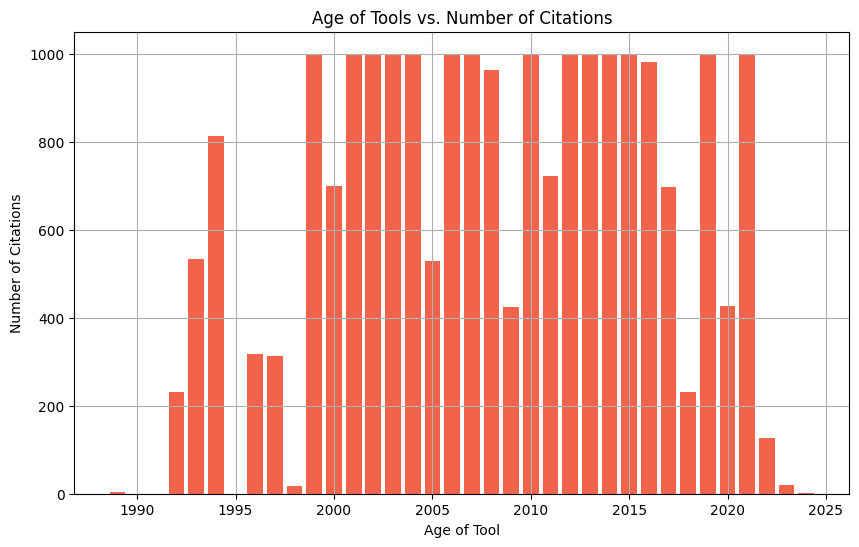

In [111]:

ages = []
citations = []

for tool, age in publication_dates.items():
    if str(tool) in nr_citations and age != 'None':
        ages.append(int(age))
        citations.append(nr_citations[str(tool)])

spread = max(ages) - min(ages)
print(spread)

# Scatter plot to show correlation
plt.figure(figsize=(10, 6))
plt.bar(ages, citations)
plt.title('Age of Tools vs. Number of Citations')
plt.xlabel('Age of Tool')
plt.ylabel('Number of Citations')
plt.grid(True)
plt.show()
